# AutoML for Regression Model Screening

The following are the steps for using AutoML for a regression task:

_Note: Setting the flag for featurization= 'True' generates represents molecules using 5 representation techniques._ 

1. Requires an input pandas dataframe consisting of two columns:<br>
    * SMILES strings<br>
    * target property values<br>


2. If featurization = True, Molecules are represented as:<br>
    * Coulomb matrix<br>
    * RDKit Morgan (ECFP6 1024-bit) fingerprints<br>
    * MACCs keys<br>
    * RDKit hashed topological torsion<br>
    * RDKit molecular descriptors (all)<br>
    * Mordred molecular descriptors (currently using base Mordred)<br>


3. Screens through various regressor models:<br>
    * Single-core (runs regardless of multi_core value):
        * [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)<br>
        * [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)<br>
        * [SVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) (if n_datapoints<500)<br>
        * [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)<br>
        * [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)<br>
    * Multi-core(set multi_core=True):
        * [MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html) (if n_datapoints<=500)<br>
        * [GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html) (if n_datapoints<=500)<br>
        * [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)<br>
        * [ChemML_MLP](https://hachmannlab.github.io/chemml/ipython_notebooks/ml_model.html) (if n_datapoints>500)<br>
        * (optional) [XGBRegressor](https://xgboost.readthedocs.io/en/latest/python/python_api.html)<br>
        * (optional) [LightGBM](https://lightgbm.readthedocs.io/en/stable/)

Yields 'n-best' models, with optimized hyperparamters.

The output_dir argument specifies a folder that will be created wherever the code is run from, containing the following directory tree:

<pre> &lt;output_dir&gt;/<br> |-- output.log<br> |-- scores.csv<br> |-- best_model/<br> |   |-- model.pkl # most non-MLP models<br> |   |-- model_chemml_model.json # MLP case (plus possible extra model files)<br> |   |-- scaler.pkl # present when scaler exists for chosen feature_key<br> |   |-- feature_order.json<br> |   |-- metadata.json<br> |-- .model_screener_artifacts/<br> |   |-- &lt;run_key_1&gt;/<br> |        |-- model.pkl # or MLP artifact files<br> |   |-- &lt;run_key_2&gt;/<br>... </pre>

## Load your data 

We are using ChemML's in-built dataset to demonstrate the minimum requirements to run AutoML.

In [1]:
import pandas as pd
from chemml.datasets import load_organic_density

In [2]:
molecules, target, dragon_subset = load_organic_density()
df=pd.concat([molecules, target], axis=1)
df = df.sample(200, random_state=42)
df

,smiles,density_Kg/m3
361,c1scc(n1)c1ncc(s1)c1c(ccc2c1cccc2)c1cncs1,1328.35
73,S1CC(SC(C1)C1CCCC1)c1cocc1c1ccccc1,1143.80
374,N1CNC(NC1)c1sccc1C1(CSCCS1)c1cccs1,1351.33
155,c1nc(c(s1)c1nsnc1)c1csc(n1)c1cccs1,1466.57
104,Oc1ccc2c(c1c1cocc1)c(ccc2)c1ccccn1,1207.67
...,...,...
248,Oc1ncc(c(c1)C)c1cnccn1,1195.16
145,Sc1cc2ccccc2c(c1)c1cnccc1c1cnccn1,1213.41
92,c1sc(c(c1)c1ncccc1c1nsnc1)c1ccc2c(c1)cccc2,1264.16
152,N1CNC(NC1)(N1CNC(NC1)c1cncs1)c1cccc2c1cccc2,1270.40


## Run autoML for a regression task

Since we have not provided any feature set, we can use AutoML's in-built featurization to screen through feature representations and find the most suitable feature set for our data.

In [3]:
from chemml.autoML import ModelScreener
MS = ModelScreener(df, target="density_Kg/m3", featurization=True, smiles="smiles", 
                   screener_type="regressor", output_dir="automl_results")
scores = MS.screen_models(n_best=10, multi_core=False)



-------------------------ChemML AutoML Model Screening-------------------------

-------------------------Model screening started at Mon Aug 31 01:37:15 2026-------------------------



Converting SMILES to ChemML Molecule objects...



Converting SMILES to ChemML Molecule objects: 100%|██████████| 200/200 [00:06<00:00, 29.03it/s]



Generating Coulomb matrix representation...

featurizing molecules in batches of 12 ...
200/200 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step
Merging batch features ...    [DONE]

Generating RDKit fingerprint representations...



Generating MACCS Fingerprints: 100%|██████████| 200/200 [00:00<00:00, 1264.05molecule/s]
Generating Hashed Topological Torsion Fingerprints: 100%|██████████| 200/200 [00:00<00:00, 6718.20molecule/s]
Generating Atom Pair Fingerprints: 100%|██████████| 200/200 [00:00<00:00, 7265.51molecule/s]



Generating RDKit descriptor representations...

Step 1: Normalizing molecule input


Step 2: Calculating RDKit descriptors: 100%|██████████| 200/200 [00:02<00:00, 94.76it/s] 



Generating Mordred descriptor representations...

Step 1: Normalizing molecule input


Normalizing Molecule input: 100%|██████████| 200/200 [00:00<00:00, 514007.84it/s]


Step 2/3: Optimizing geometry for 3D descriptor calculation


3D geometry already exists, loading geometry: 100%|██████████| 200/200 [00:00<00:00, 77129.53it/s]

Step 3/3: Calculating Mordred descriptors



100%|██████████| 200/200 [00:06<00:00, 32.11it/s]



Cleaning feature sets to remove constant, highly correlated, low-variance, and complex features...

Feature set 'CoulombMatrix' cleaned: 25 features retained.

Feature set 'morganfingerprints_radius3' cleaned: 252 features retained.

Feature set 'MACCS_radius3' cleaned: 48 features retained.

Feature set 'hashedtopologicaltorsion_radius3' cleaned: 76 features retained.

Feature set 'hashedatompair_radius3' cleaned: 421 features retained.

Feature set 'rdkit_descriptors' cleaned: 90 features retained.

Feature set 'mord_descriptors' cleaned: 530 features retained.


-------------------------Run parameters-------------------------
  Featurization: True
  Multi_core: False
  Screener_type: regressor
  Number of datapoints: 200
  Note: Dataset <= 500 samples; MLP is excluded from screening due to inefficiency.

split done!
Single-core complete 


------------------------- Screening complete for feature set CoulombMatrix, time taken: 10.8 seconds -------------------------

split done!
Sing

In [4]:
scores

,ME,MAE,MSE,RMSE,MSLE,RMSLE,MAPE,MaxAPE,RMSPE,MPE,MaxAE,deltaMaxE,r_squared,time(seconds),Model,parameters,Feature,run_key
33,4.552818,11.553280,181.728198,13.480660,0.000114,0.010676,0.910524,2.579643,1.062078,0.353552,33.017888,45.542634,0.980328,4.930333,Lasso,"{'alpha': 0.10000000000000002, 'copy_X': True,...",mord_descriptors,Lasso_mord_descriptors_3a7194cd47ba458d8ba38a4...
30,3.515362,10.915172,188.539081,13.730953,0.000124,0.011143,0.869834,2.193016,1.108684,0.290819,28.069291,47.432492,0.979591,1.207374,Ridge,"{'alpha': 63.800000000000004, 'copy_X': True, ...",mord_descriptors,Ridge_mord_descriptors_c196269642bc48e1ac9f745...
34,3.687586,10.678849,191.563700,13.840654,0.000122,0.011051,0.843186,2.740330,1.099991,0.299250,35.074581,57.654403,0.979263,5.995100,ElasticNet,"{'alpha': 0.06951927961775611, 'copy_X': True,...",mord_descriptors,ElasticNet_mord_descriptors_516936b2cb4d4804af...
31,4.483152,11.853263,232.867162,15.259986,0.000144,0.012013,0.928513,2.919669,1.198157,0.343363,37.370005,66.251821,0.974792,2.749953,SVR,"{'C': 1.0, 'cache_size': 200, 'coef0': 0.0, 'd...",mord_descriptors,SVR_mord_descriptors_f44f5f430c6043969a4062edb...
27,4.182179,16.889614,476.895174,21.837930,0.000284,0.016856,1.318434,4.192188,1.674893,0.308835,61.499391,97.646100,0.948376,1.832462,Lasso,"{'alpha': 0.10000000000000002, 'copy_X': True,...",rdkit_descriptors,Lasso_rdkit_descriptors_91aafe99bf1344fe8545c7...
26,4.139097,17.790071,496.914400,22.291577,0.000297,0.017234,1.389557,4.205474,1.713232,0.310069,61.694307,98.196240,0.946209,0.783303,Ridge,"{'alpha': 5.0, 'copy_X': True, 'fit_intercept'...",rdkit_descriptors,Ridge_rdkit_descriptors_8e884cb01ad148408712ef...
28,4.401149,18.037694,503.715533,22.443608,0.000301,0.017348,1.408142,4.234329,1.724064,0.330047,62.117602,98.276555,0.945473,1.884814,ElasticNet,"{'alpha': 0.10000000000000002, 'copy_X': True,...",rdkit_descriptors,ElasticNet_rdkit_descriptors_19bde069eb2649ecb...
29,5.004877,19.254586,623.825962,24.976508,0.000380,0.019482,1.513790,4.573626,1.934141,0.382821,67.095092,105.112449,0.932471,13.696179,SVR,"{'C': 11.421052631578947, 'cache_size': 200, '...",rdkit_descriptors,SVR_rdkit_descriptors_b46b8047cc1a428298ed35da...
25,7.912750,27.688750,1137.561421,33.727754,0.000713,0.026710,2.159354,6.548075,2.645154,0.525923,78.700000,134.570000,0.876860,1.285904,DecisionTreeRegressor,"{'ccp_alpha': 0.0, 'criterion': 'absolute_erro...",rdkit_descriptors,DecisionTreeRegressor_rdkit_descriptors_b102e2...
21,-4.632258,25.970876,1146.052758,33.853401,0.000693,0.026329,2.024358,7.226699,2.680475,-0.414917,87.839081,133.848639,0.875940,1.143952,Ridge,"{'alpha': 78.5, 'copy_X': True, 'fit_intercept...",hashedatompair_radius3,Ridge_hashedatompair_radius3_7c27bb60e96049318...


## Validating AutoML-generated model

Since ChemML v1.3.4, AutoML outputs the best model and required scaler and feature order as easy-to-import files. A quick demonstration of the model loading workflow is given below:

In [5]:
import pickle
import json

with open('automl_results/best_model/metadata.json', 'r') as f:
    metadata = json.load(f)
with open('automl_results/best_model/explanation.json', 'r') as f:
    explanation = json.load(f)
with open('automl_results/best_model/feature_order.json', 'r') as f:
    feature_order = json.load(f)
with open("automl_results/best_model/model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
with open("automl_results/best_model/scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

Metadata isn't necessary for model validation, but gives us a lot of context from the AutoML screening workflow.

In [6]:
metadata

{'artifact_schema_version': 1,
 'model_name': 'Lasso',
 'feature_key': 'mord_descriptors',
 'run_key': 'Lasso_mord_descriptors_3a7194cd47ba458d8ba38a4c42e3dc6d',
 'screener_type': 'regressor',
 'parameters': {'alpha': 0.10000000000000002,
  'copy_X': True,
  'fit_intercept': True,
  'max_iter': 1000,
  'positive': False,
  'precompute': False,
  'random_state': None,
  'selection': 'cyclic',
  'tol': 0.0001,
  'warm_start': False},
 'n_folds': 5,
 'n_datapoints': 200,
 'metrics': {'ME': 4.552817883339197,
  'MAE': 11.553280063774162,
  'MSE': 181.72819797227447,
  'RMSE': 13.480660146011934,
  'MSLE': 0.00011396673759956667,
  'RMSLE': 0.010675520483778142,
  'MAPE': 0.9105242223102075,
  'MaxAPE': 2.5796433993517534,
  'RMSPE': 1.0620775201892783,
  'MPE': 0.35355188263843224,
  'MaxAE': 33.01788772566283,
  'deltaMaxE': 45.5426336527853,
  'r_squared': 0.980328032332101,
  'time(seconds)': 4.930333375930786},
 'model_serializer': 'pickle',
 'model_artifact_dir': 'model_artifact',
 's

Explanation gives the user a list of feature importances alongside feature names; while not necessary for validation, this is useful to understand what features the model is actually using

In [7]:
explanation

{'model_type': 'Lasso',
 'explanation_type': 'linear.coef_',
 'importance_values': {'AATSC0Z': 28.012900357435722,
  'AATS1se': 27.583120713121403,
  'AMID_h': 12.055038066747914,
  'MIC2': 10.045620227882683,
  'GATS2i': -9.042124462668491,
  'GATS1p': -7.354977238746177,
  'SpDiam_A': 6.726688403957051,
  'C2SP3': -5.591252791033305,
  'Mor06p': 5.2500775423204304,
  'AATS8dv': 4.8109148833883,
  'ZMIC4': 4.683909744557295,
  'GATS7s': -4.2733394067530215,
  'NaaN': 4.0778101734185075,
  'NsCH3': -4.031087808617084,
  'ATSC1pe': -3.9878753533945037,
  'Mor27m': 3.9049517797044606,
  'ATSC2d': -3.6164709139902325,
  'MDEC-22': -3.3562645191398004,
  'MATS7s': -3.3299319725002325,
  'Mor31': -3.233335107924634,
  'VSA_EState1': 3.096026758544977,
  'AATSC3Z': -2.9299423458120306,
  'AATS7se': 2.8514396676457734,
  'GATS8Z': 2.7909016705914294,
  'ATSC1i': -2.6094166454339014,
  'Mor08': -2.3210227304435325,
  'Mor32m': 2.311053179367852,
  'AATS7dv': 2.2720719610502043,
  'GATS6c': -2.

feature_order ensures that the trained model sees features in the exact same order as trained.

In [8]:
feature_order[:5]

['ABC', 'ABCGG', 'nBase', 'SpDiam_A', 'nAromAtom']

In [9]:
from chemml.chem import Molecule
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tqdm
from chemml.chem import Mordred
from sklearn.svm import SVR

mol_objs_list = []
for i, smi in enumerate(tqdm.tqdm(df["smiles"], desc="Converting SMILES to ChemML Molecule objects")):
    mol = Molecule(smi, 'smiles')
    mol.hydrogens('add')
    try:
        mol.to_xyz('MMFF', maxIters=10000, mmffVariant='MMFF94s')
        mol_objs_list.append(mol)
    except Exception as e:
        print(f"\nUnable to process SMILES: {smi}; Error: {e}")
        # self.discarded_indices.append(i)
loaded_mols = mol_objs_list
features = Mordred(ignore_3D=False).represent(loaded_mols).drop(columns=['SMILES'])[feature_order].values
targets = df["density_Kg/m3"].values


X_test = loaded_scaler.transform(features)

y_pred = loaded_model.predict(X_test)

Converting SMILES to ChemML Molecule objects: 100%|██████████| 200/200 [00:06<00:00, 29.14it/s]


Step 1: Normalizing molecule input
Step 2/3: Optimizing geometry for 3D descriptor calculation
Step 3/3: Calculating Mordred descriptors


The loaded_model object can be treated just like any model object

In [10]:
loaded_model

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(0....0000000000002)
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [11]:
targets[:5], y_pred[:5]

(array([1328.35, 1143.8 , 1351.33, 1466.57, 1207.67]),
 array([1332.70141881, 1145.09482801, 1347.18620498, 1472.06678856,
        1204.79752648]))

In [12]:
from chemml.utils import regression_metrics
regression_metrics(targets, y_pred)

,ME,MAE,MSE,RMSE,MSLE,RMSLE,MAPE,MaxAPE,RMSPE,MPE,MaxAE,deltaMaxE,r_squared,std
0,0.455282,3.698161,29.72562,5.452121,0.000019,0.00435,0.294964,2.579643,0.433903,0.033271,33.017888,45.542634,0.996445,91.441066


The Plot has been saved at:  .\automl_results/val/images/Parity.png


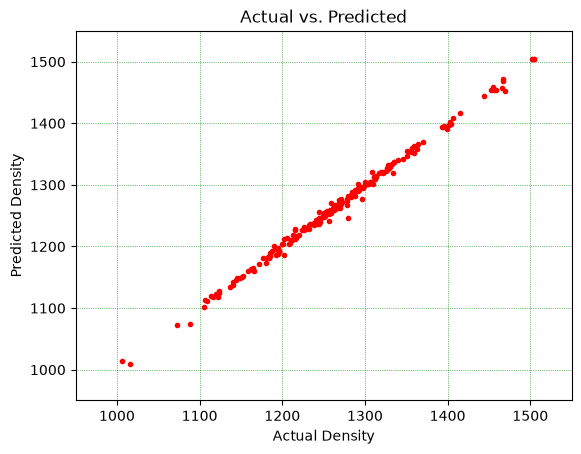

In [13]:
from chemml.visualization import scatter2D, SavePlot, decorator
import pandas as pd
%matplotlib inline
df_viz = pd.DataFrame()
df_viz["Actual"] = targets.reshape(-1,)
df_viz["Predicted"] = y_pred.reshape(-1,)
sc = scatter2D('r', marker='.')
fig = sc.plot(dfx=df_viz, dfy=df_viz, x="Actual", y="Predicted")

dec = decorator(title='Actual vs. Predicted',xlabel='Actual Density', ylabel='Predicted Density',
                xlim= (950,1550), ylim=(950,1550), grid=True, 
                grid_color='g', grid_linestyle=':', grid_linewidth=0.5)
fig = dec.fit(fig)
# print(type(fig))
sa=SavePlot(filename='Parity',output_directory='automl_results/val/images',
            kwargs={'facecolor':'w','dpi':330,'pad_inches':0.1, 'bbox_inches':'tight'})
sa.save(obj=fig)
fig.show()